In [38]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Time Series
from statsmodels.tsa.arima.model import ARIMA



In [39]:


# Raw GitHub link to your CSV
url = "https://raw.githubusercontent.com/SouravDataPro/Retail-Sales-Performance-Tracking-and-Analysis/main/Retail_Sales_Dataset.csv"

# Load CSV directly from GitHub
df = pd.read_csv(url)

# Check data
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [40]:
df.shape


(1000, 9)

In [41]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [42]:
df.isnull().sum()


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [43]:
df.duplicated().sum()




np.int64(0)

In [44]:
df['Date'] = pd.to_datetime(df['Date'])


In [45]:
numeric_cols = ['Quantity', 'Price per Unit', 'Total Amount', 'Age']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


Data Transformation / Feature Engineering

In [46]:
df['Total_Sales'] = df['Quantity'] * df['Price per Unit']


In [47]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [48]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year


In [49]:
le = LabelEncoder()

df['Gender_Enc'] = le.fit_transform(df['Gender'])
df['Category_Enc'] = le.fit_transform(df['Product Category'])


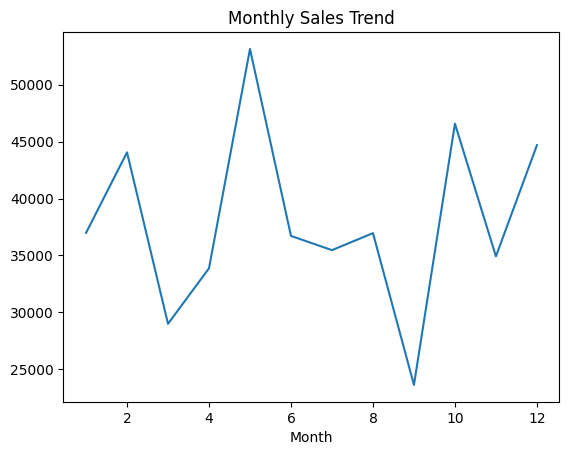

In [50]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.show()


Sales Trend Forecasting (Time Series)


In [51]:
ts_data = df.groupby('Date')['Total_Sales'].sum()
ts_data = ts_data.resample('M').sum()


/tmp/ipython-input-1392369740.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = ts_data.resample('M').sum()


In [52]:
model = ARIMA(ts_data, order=(1,1,1))
model_fit = model.fit()


In [53]:
forecast = model_fit.forecast(steps=3)
forecast


,predicted_mean
2024-02-29,34890.525393
2024-03-31,32677.219581
2024-04-30,32824.061472


Sales Prediction (ML Models)

In [54]:
X = df[['Quantity', 'Age', 'Gender_Enc', 'Category_Enc', 'Month']]
y = df['Total_Sales']


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [56]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [57]:
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF R2:", r2_score(y_test, y_pred_rf))


RF MAE: 430.35483452380953
RF R2: -0.01746203310091987


Gradient Boosting (GBM)

In [58]:
gbm = GradientBoostingRegressor()
gbm.fit(X_train, y_train)

y_pred_gbm = gbm.predict(X_test)
print("GBM MAE:", mean_absolute_error(y_test, y_pred_gbm))
print("GBM R2:", r2_score(y_test, y_pred_gbm))


GBM MAE: 444.1703164789089
GBM R2: -0.01773429088699774


Customer Segmentation (K-Means)

In [59]:
customer_df = df.groupby('Customer ID').agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum',
    'Transaction ID': 'count'
}).reset_index()


In [60]:
customer_df.columns = ['CustomerID', 'Total_Spent', 'Total_Quantity', 'Frequency']


In [61]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_df[['Total_Spent', 'Frequency']])


In [62]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_data)


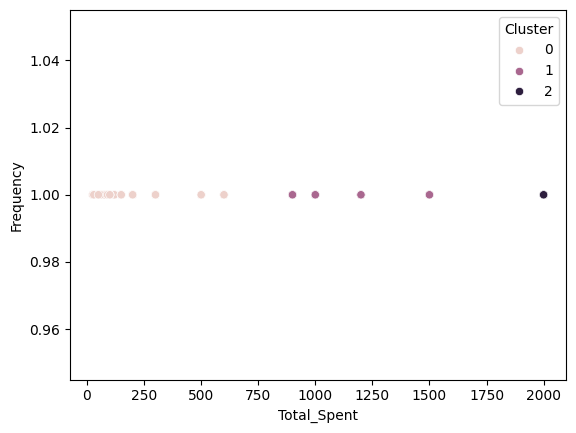

In [63]:
sns.scatterplot(
    x='Total_Spent',
    y='Frequency',
    hue='Cluster',
    data=customer_df
)
plt.show()


Customer Lifetime Value (CLV)

In [64]:
customer_df['Avg_Order_Value'] = (
    customer_df['Total_Spent'] / customer_df['Frequency']
)

customer_df['CLV'] = (
    customer_df['Avg_Order_Value'] * customer_df['Frequency']
)

customer_df.head()



,CustomerID,Total_Spent,Total_Quantity,Frequency,Cluster,Avg_Order_Value,CLV
0,CUST001,150,3,1,0,150.0,150.0
1,CUST002,1000,2,1,1,1000.0,1000.0
2,CUST003,30,1,1,0,30.0,30.0
3,CUST004,500,1,1,0,500.0,500.0
4,CUST005,100,2,1,0,100.0,100.0


In [65]:
df.to_csv("corrected_sales_data.csv", index=False)


In [66]:
from google.colab import files
files.download("corrected_sales_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>